In [4]:
import numpy as np
np.random.seed(123)
import random 
random.seed(123)
import datetime
import tensorflow as tf
from tensorflow.keras import Sequential, layers
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, UpSampling2D
import matplotlib.pyplot as plt
import config
from Generator import DataGenerator
from CustomLossFunction import DiceLoss
import pandas as pd
from tensorflow.keras.utils import plot_model

In [5]:
# tf.debugging.experimental.enable_dump_debug_info(config.DEBUG_DIR, tensor_debug_mode="FULL_HEALTH", circular_buffer_size=1000)

In [6]:
# tf.debugging.set_log_device_placement(True) 
tf.config.experimental.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:XLA_CPU:0', device_type='XLA_CPU'),
 PhysicalDevice(name='/physical_device:XLA_GPU:0', device_type='XLA_GPU')]

In [7]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  try:
    tf.config.experimental.set_memory_growth(gpus[0], True)
#     tf.config.experimental.set_virtual_device_configuration(gpus[0], [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=1000, experimental_priority=-2)])
  except RuntimeError as e:
    print(e)

In [8]:
tf.config.experimental.list_logical_devices()

[LogicalDevice(name='/device:CPU:0', device_type='CPU'),
 LogicalDevice(name='/device:XLA_CPU:0', device_type='XLA_CPU')]

In [9]:
# filenames = os.listdir(config.IMAGES_PATH)
with tf.device('/device:CPU:0'):
    df = pd.read_csv(config.ANNOTS_PATH)
    df = df[df['Coarse_lesion_type'] != -1]

    def subset(df, lesion_type, num):
        fns = list(df[df['Coarse_lesion_type'] == lesion_type]['File_name'])
        random.shuffle(fns)
        return fns[:num]

    fns_list = []
    for i in range(1,9):
        fns_list.extend(subset(df, i, 10))

    filenames1 = fns_list[:]
    # filenames2 = fns_list[-20:]


    datagen = DataGenerator(filenames1, config.IMAGES_PATH, config.ANNOTS_PATH, batch_size=config.BATCH_SIZE, targets=['Coarse_lesion_type', 'Bounding_boxes'])
    # valgen = DataGenerator(filenames2, config.IMAGES_PATH, config.ANNOTS_PATH, targets=['Coarse_lesion_type', 'Bounding_boxes'])

In [10]:
with tf.device('/device:CPU:0'):
    model = Sequential(name='MyModel')
    model.add(tf.keras.layers.Input(shape=(512,512,3), batch_size=config.BATCH_SIZE))
    vgg16mod = tf.keras.applications.vgg16.VGG16(include_top=False, input_shape=(512, 512, 3))
    for i in tf.keras.applications.vgg16.VGG16(include_top=False, input_shape=(512, 512, 3)).layers[1:]:
#         print(model.summary())
        if i.name in ['block4_pool','block5_pool']:
            continue
        elif i.name == 'block1_conv1':
            initial_weights = i.get_weights()
            weights = np.mean(initial_weights[0], axis=2)
            weights.resize((3,3,1, initial_weights[0].shape[-1]))
            weights = np.repeat(weights, 3, axis=2)
            new = Conv2D(i.get_config()['filters'], i.get_config()['kernel_size'], padding='same')
            model.add(new)
            model.layers[-1].set_weights([weights, initial_weights[1]])
        elif i.name in ['block1_conv2', 'block2_conv1', 'block2_conv2']:
            initial_weights = i.get_weights()
            new = Conv2D.from_config(i.get_config())
            model.add(new)
            model.layers[-1].set_weights(initial_weights)
        elif 'conv' in i.name:
            initial_weights = i.get_weights()
#             new = Conv2D(i.get_config()['filters'], i.get_config()['kernel_size'])
            new = Conv2D.from_config(i.get_config())
            model.add(new)
            model.layers[-1].set_weights(initial_weights)
        elif 'pool' in i.name:
            new = layers.MaxPooling2D.from_config(i.get_config())
            model.add(new) 
    

with tf.device('/device:GPU:0'):
    model.add(Conv2D(512, (3, 3)))

    print(model.summary())

Model: "MyModel"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (8, 512, 512, 64)         1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (8, 512, 512, 64)         36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (8, 256, 256, 64)         0         
_________________________________________________________________
block2_conv1 (Conv2D)        (8, 256, 256, 128)        73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (8, 256, 256, 128)        147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (8, 128, 128, 128)        0         
_________________________________________________________________
block3_conv1 (Conv2D)        (8, 128, 128, 256)        2951

In [11]:
with tf.device('/device:CPU:0'):
    softmaxHead = Conv2D(512, (5, 5), strides=1, padding='same')(model.output)
    softmaxHead = Flatten()(softmaxHead)
    softmaxHead = Dense(128, activation="relu")(softmaxHead)
with tf.device('/device:GPU:0'):
    softmaxHead = Dense(32, activation="relu")(softmaxHead)
    softmaxHead = Dense(8, activation="softmax",
        name="class_label")(softmaxHead)

In [12]:
# flatten = model.output
with tf.device('/device:CPU:0'):

    bboxHead = layers.ZeroPadding2D(padding=(1,1))(model.output)
    bboxHead = UpSampling2D(size=(2,2))(bboxHead)
    bboxHead = UpSampling2D(size=(2,2))(bboxHead)
    bboxHead = UpSampling2D(size=(2,2))(bboxHead)
#     bboxHead = Dense(128, activation="relu")()
with tf.device('/device:GPU:0'):
    bboxHead = Dense(256, activation="tanh")(bboxHead)
    bboxHead = Dense(1, activation="sigmoid",
        name="bounding_box")(bboxHead)

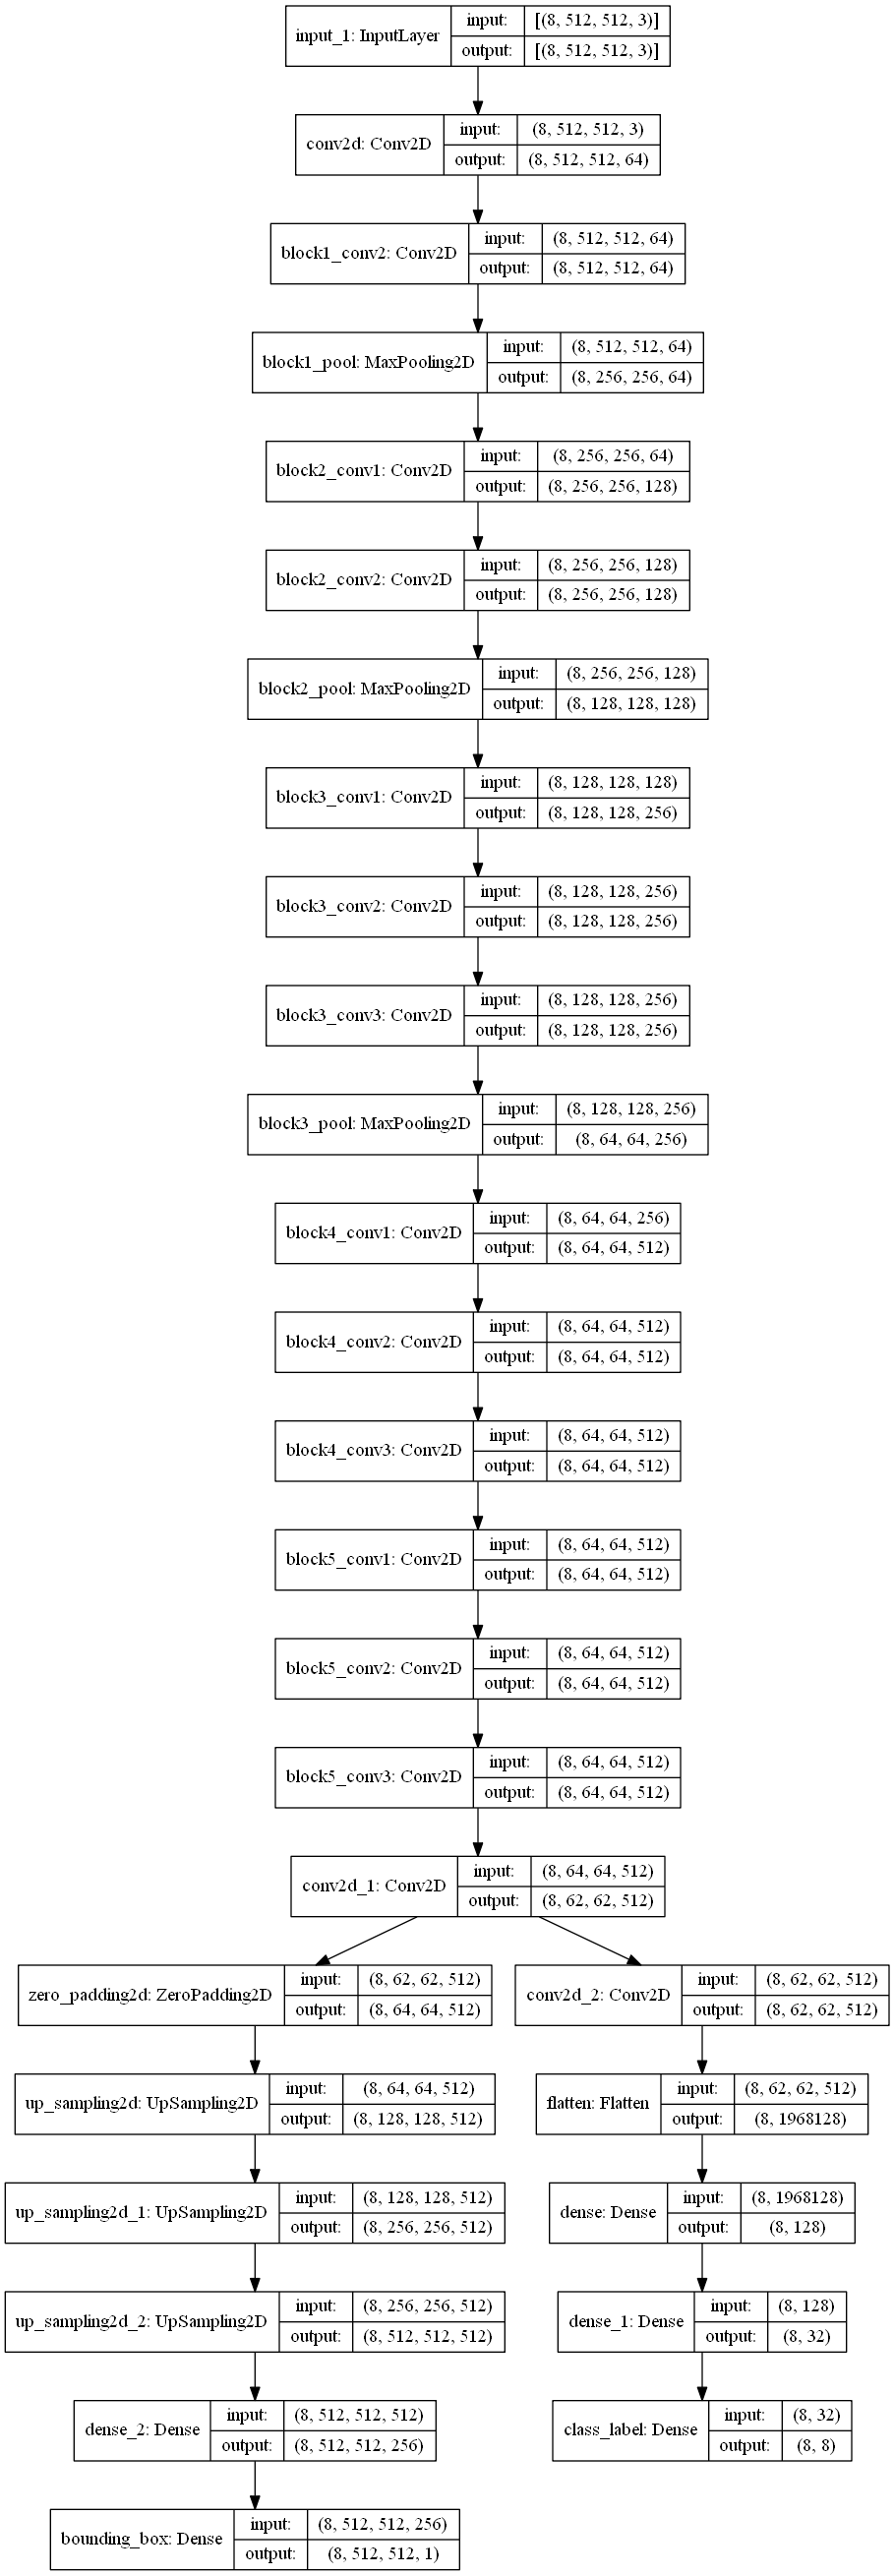

In [13]:
# inputs = tf.keras.Input(shape=(512,512,3), batch_size=32)
# inputs = model(inputs)

# with tf.device('/device:CPU:0'):
model = tf.keras.models.Model(inputs=model.inputs, outputs=[softmaxHead, bboxHead])
plot_model(model, show_shapes=True)
# print(model.summary())

In [14]:
with tf.device('/device:CPU:0'):
    losses = {
        "class_label": tf.keras.losses.categorical_crossentropy,
        "bounding_box": DiceLoss,
    }


    cbs =[
        tf.keras.callbacks.EarlyStopping(patience=2),
        tf.keras.callbacks.ModelCheckpoint(filepath='model.{epoch:02d}-{loss:.2f}.h5'),
        tf.keras.callbacks.TensorBoard(histogram_freq=1, write_images=True, profile_batch=(2,5), update_freq='batch', log_dir=f'./logs/fit/{datetime.datetime.now().strftime("%Y%m%d-%H%M%S")}'
),
    ]
with tf.device('/device:GPU:0'):
    opt = tf.keras.optimizers.Adam(1e-4, clipnorm=1)
    model.compile(optimizer=opt, loss=losses)

In [15]:
with tf.device('/device:CPU:0'):
    H = model.fit(x=datagen, epochs=3, workers=16, callbacks=cbs, max_queue_size=4)

Epoch 1/3


KeyboardInterrupt: 

In [ ]:
print("[INFO] saving object detector model...")
model.save(config.MODEL_PATH, save_format="h5")
# plot the model training history
N = 5# config.NUM_EPOCHS
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.title("Bounding Box Regression Loss on Training Set")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend(loc="lower left")
plt.savefig(config.PLOT_PATH)